# DE EIA - Projets applicatifs

2025-26 - Bordeaux INP - ENSEIRB-MATMECA

Michaël Clément

## Détection de la maladie d'Alzheimer à partir d'IRM du cerveau

Ce projet a pour objectif de développer un modèle de deep learning capable de classifier la maladie d'Alzheimer à partir d'IRM du cerveau.

Ce type d'outil peut notamment aider au diagnostic précoce de la maladie.

Le dataset que nous allons utiliser est tiré du projet Alzheimer's Disease Neuroimaging Initiative (ADNI). Il comprend plus de 700 IRM 3D d'environ 200x200x200 voxels, avec une résolution anatomique d'environ 1 mm par voxel.

Ces IRM sont réparties en plusieurs catégories cliniques :

- Cognitively Normal (CN) : sujets sains
- Alzheimer’s Disease (AD) : patients atteints de la maladie d'Alzheimer
- Mild Cognitive Impairment (MCI) : patients présentant des troubles cognitifs légers. Parmi les MCI, on distingue :
    - Stable MCI (sMCI) : troubles stables.
    - Progressive MCI (pMCI) : troubles évoluant vers l'AD.

D’un point de vue clinique, la distinction entre sMCI et pMCI est cruciale, car elle aide à identifier les patients à plus haut risque de progresser vers la maladie d’Alzheimer.

Cependant, les données sont souvent limitées pour ces catégories. En imagerie médicale, il est donc courant d'entraîner des modèles sur la classification CN/AD, puis de tester leur capacité à distinguer les cas sMCI/pMCI.

### Approches possibles

- Une approche simplifiée en utilisant une seule coupe d'IRM. Les images correspondant à la coupe axiale centrale de chaque volume vous sont fournies. L'objectif sera de mettre en place un système de classification CN/AD à partir de ces images 2D.
- Cette approche pourrait être étendue à du 2,5D, ou l'on va traiter un ensemble de coupes selon un ou plusieurs axes. Les coupes sont données comme des canaux supplémentaires et le réseau reste en 2D.
- Un modèle 3D peut être mis en place afin de prendre en compte tout le volume ou un sous-volume (par exemple la région de l'hippocampe). Attention, cette approche est très couteuse en mémoire et en temps de calcul, il sera nécessaire de diminuer fortement la taille des volumes et l'entraînement prendra plus de temps.

Le code de démarrage fourni vous permet de charger les données soit au format 2D (coupe axiale centrale), soit au format 3D (volumes complets), en spécifiant bien les chemins vers les répertoires des données 2D ou 3D que vous aurez téléchargé.
Les labels et les splits train/test sont spécifiés dans des fichiers `.txt` également fournis avec le sujet.

## Initialisation

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import numpy as np
import skimage
import nibabel
import matplotlib.pyplot as plt
import os


In [10]:
class AdniDataset(Dataset):
    def __init__(self, data_file_path, data_dir, mode='2d', transform=None):
        # Vérification du mode de chargement
        if mode not in ['2d', '3d']:
            raise ValueError("Le mode doit être '2d' ou '3d'.")
        # Initialisation des attributs du dataset
        self.mode = mode
        self.data_dir = data_dir
        self.transform = transform
        self.samples = []
        self.label_names = {0: 'CN', 1: 'AD', 2: 'sMCI', 3: 'pMCI'}
        # Lecture du fichier .txt d'entrée pour collecter les bases des noms de fichiers et leurs labels
        with open(data_file_path, 'r') as f:
            for line in f:
                line = line.strip()
                if not line: continue
                # Diviser la ligne en base du nom de fichier et label, puis convertir le label en entier
                filename_base_from_txt, label_str = line.split(',')
                label = int(label_str)
                self.samples.append((filename_base_from_txt, label)) # Ajouter l'échantillon à la liste
        
    def __len__(self):
        # Retourne le nombre total d'échantillons dans le dataset
        return len(self.samples)

    def __getitem__(self, idx):
        # Convertir idx en int si nécessaire (DataLoader peut passer d'autres types numériques)
        idx = int(idx)

        # Récupère la base du nom de fichier et le label pour l'échantillon donné
        filename_base, label = self.samples[idx]

        # Chargement des données en mode 2D (coupe axiale PNG)
        if self.mode == '2d':
            slice_filename_png = f"{filename_base}.png"
            slice_path = os.path.join(self.data_dir, slice_filename_png)
            
            # Charge l'image PNG avec skimage en niveaux de gris
            img_np = skimage.io.imread(slice_path, as_gray=True)
            tensor = torch.tensor(img_np, dtype=torch.float32).unsqueeze(0) 
        
        # Chargement des données en mode 3D (volume IRM complet)
        elif self.mode == '3d':
            filename_full = f"{filename_base}.nii.gz"
            img_path = os.path.join(self.data_dir, filename_full)
            
            # Charge le volume IRM 3D avec nibabel
            img = nibabel.load(img_path)
            data = np.array(img.get_data())
            tensor = torch.tensor(data, dtype=torch.float32).unsqueeze(0) 

        if self.transform:
            tensor = self.transform(tensor)
            
        return tensor, torch.tensor(label, dtype=torch.long)

In [11]:
# Fonctions d'entraînement et évaluation
def train_epoch(model, dataloader, loss_fn, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = total = 0
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * X.size(0)
        correct += (y_pred.argmax(dim=1) == y).sum().item()
        total += y.size(0)
    
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_accuracy = correct / total
    return epoch_loss, epoch_accuracy

def eval_epoch(model, dataloader, loss_fn, device):
    model.eval()
    running_loss = 0.0
    correct = total = 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            loss = loss_fn(y_pred, y)
            
            running_loss += loss.item() * X.size(0)
            correct += (y_pred.argmax(dim=1) == y).sum().item()
            total += y.size(0)
    
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_accuracy = correct / total
    return epoch_loss, epoch_accuracy


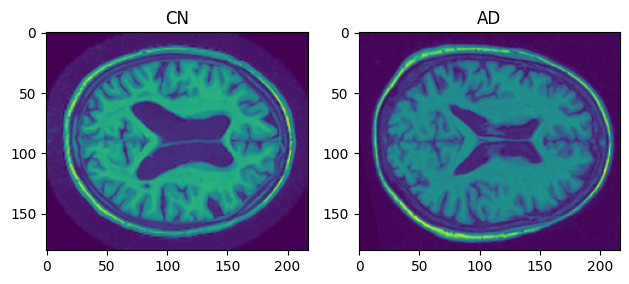

In [12]:
adni = AdniDataset('dataset/train_adcn.txt', 'dataset/2D_slices/', mode='2d')

plt.subplot(121)
im, y = adni[0]
plt.imshow(im[0])
plt.title(f'{adni.label_names[y.item()]}')

plt.subplot(122)
im, y = adni[2]
plt.imshow(im[0])
plt.title(f'{adni.label_names[y.item()]}')
plt.tight_layout()

### Affichage des données

On affiche quelques IRM 2D de cerveaux sains et malades.

Les différences principales entre une IRM d'un cerveau atteint d'Alzheimer et un cerveau sain incluent par exemple "une diminution du volume cérébral global, particulièrement au niveau de l'hippocampe.".

On ne sait pas identifier ce genre d'information à l'oeil nu.

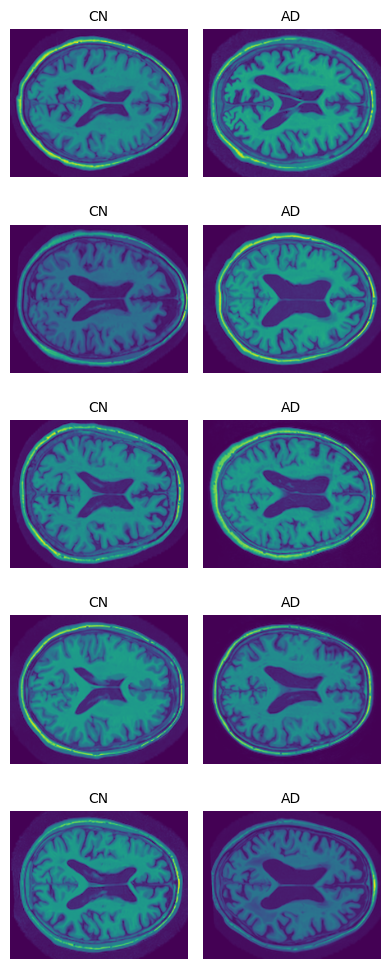

In [13]:
# Afficher 10x2 images aléatoires : CN (gauche) et AD (droite)
fig, axes = plt.subplots(5, 2, figsize=(4, 10))

# Obtenir les indices des images CN (label 0) et AD (label 1)
cn_indices = [i for i in range(len(adni)) if adni.samples[i][1] == 0]
ad_indices = [i for i in range(len(adni)) if adni.samples[i][1] == 1]

# Mélanger et sélectionner 5 images aléatoires pour chaque label
import random
random.seed(42)
random_cn_indices = random.sample(cn_indices, min(5, len(cn_indices)))
random_ad_indices = random.sample(ad_indices, min(5, len(ad_indices)))

# Afficher les images
for row in range(5):
    # Colonne gauche : CN
    im_cn, y_cn = adni[random_cn_indices[row]]
    axes[row, 0].imshow(im_cn[0])
    axes[row, 0].set_title(adni.label_names[y_cn.item()], fontsize=10)
    axes[row, 0].axis('off')
    
    # Colonne droite : AD
    im_ad, y_ad = adni[random_ad_indices[row]]
    axes[row, 1].imshow(im_ad[0])
    axes[row, 1].set_title(adni.label_names[y_ad.item()], fontsize=10)
    axes[row, 1].axis('off')

plt.tight_layout()

### Caractéristiques du dataset

Les données d’entraînement comprennent 314 images, ce qui reste relativement limité pour un problème de classification par deep learning. Ce faible volume expose le modèle à un risque important d’overfitting. Afin d’y remédier, il sera nécessaire de recourir à des techniques de data augmentation (rotations légères, translations, éventuellement flips), tout en restant prudent : les images IRM ont été préalablement centrées et normalisées, et certaines transformations pourraient altérer la cohérence anatomique ou introduire des biais non réalistes.

En revanche, la répartition des classes est globalement équilibrée (54 % CN vs 46 % AD), ce qui constitue un point positif. Cela limite le risque de biais du modèle en faveur d’une classe majoritaire et permet d’utiliser des métriques standard sans nécessiter de rééquilibrage particulier (pondération des classes ou sampling).

In [14]:
# Chargement des datasets
train_dataset = AdniDataset('dataset/train_adcn.txt', 'dataset/2D_slices/', mode='2d')
test_dataset = AdniDataset('dataset/test_adcn.txt', 'dataset/2D_slices/', mode='2d')

# Fonction pour afficher les statistiques d'un dataset
def print_dataset_stats(dataset, dataset_name):
    print("=" * 60)
    print(f"STATISTIQUES - {dataset_name}")
    print("=" * 60)
    
    # Nombre total d'images
    total_samples = len(dataset)
    print(f"\nNombre total d'images : {total_samples}")
    
    # Taille des images
    sample_img, _ = dataset[0]
    img_shape = sample_img.shape
    print(f"\nTaille des images : {img_shape[1]} x {img_shape[2]} pixels (canaux: {img_shape[0]})")
    
    # Compter par label
    label_counts = {}
    for i in range(len(dataset)):
        label = dataset.samples[i][1]
        label_counts[label] = label_counts.get(label, 0) + 1
    
    print(f"\nRépartition par classe :")
    for label_id, count in sorted(label_counts.items()):
        label_name = dataset.label_names[label_id]
        percentage = (count / total_samples) * 100
        print(f"  {label_name} (label {label_id}): {count:4d} images ({percentage:6.2f}%)")
    
    print("\n")

# Afficher les statistiques
print_dataset_stats(train_dataset, "TRAIN SET 2D")
print_dataset_stats(test_dataset, "TEST SET 2D")

STATISTIQUES - TRAIN SET 2D

Nombre total d'images : 314

Taille des images : 181 x 217 pixels (canaux: 1)

Répartition par classe :
  CN (label 0):  171 images ( 54.46%)
  AD (label 1):  143 images ( 45.54%)


STATISTIQUES - TEST SET 2D

Nombre total d'images : 105

Taille des images : 181 x 217 pixels (canaux: 1)

Répartition par classe :
  CN (label 0):   57 images ( 54.29%)
  AD (label 1):   48 images ( 45.71%)




## Data Augmentation Offline (x6)

Augmentation des données avec sauvegarde offline des images transformées. Les images augmentées sont stockées dans un dossier séparé et les labels correspondants ajoutés aux fichiers de configuration.

Cette augmentation a été ajoutée a posteriori. Avant l'augmentation, les résultats du CNN et du ResNet18 étaient très proches de l'aléatoire (50% d'accuracy).

In [15]:
# Data Augmentation Offline - Création d'images augmentées
from scipy.ndimage import rotate, map_coordinates, gaussian_filter
from scipy import ndimage
import os
import shutil
import warnings

# Supprime l'avertissement de scikit-image concernant le faible contraste
warnings.filterwarnings('ignore', message='.*low contrast image.*')

def apply_elastic_deformation(image, sigma=5, alpha=30):
    """Applique une déformation élastique aléatoire"""
    random_state = np.random.RandomState()
    shape = image.shape
    dx = gaussian_filter((random_state.rand(*shape) * 2 - 1), sigma) * alpha
    dy = gaussian_filter((random_state.rand(*shape) * 2 - 1), sigma) * alpha
    
    x, y = np.meshgrid(np.arange(shape[0]), np.arange(shape[1]), indexing='ij')
    indices = np.reshape(x + dx, (-1, 1)), np.reshape(y + dy, (-1, 1))
    
    distorted = map_coordinates(image, indices, order=1, cval=0.0)
    return distorted.reshape(shape)

def apply_gaussian_noise(image, sigma=0.01):
    """Ajoute un léger bruit gaussien à l'image"""
    noise = np.random.normal(0, sigma, image.shape)
    noisy_image = image + noise
    return np.clip(noisy_image, 0, 1)

def augment_dataset_offline(input_dir, output_dir, train_file, augmentation_config, seed=42):
    """
    Augmente les données offline et sauvegarde les images transformées.
    L'augmentation est appliquée UNIQUEMENT au training set.
    
    Args:
        input_dir (str): Chemin vers le dossier contenant les images originales
        output_dir (str): Chemin vers le dossier de destination pour les images augmentées
        train_file (str): Chemin vers le fichier train_adcn.txt
        augmentation_config (dict): Dictionnaire {stratégie: facteur}
            Stratégies disponibles: 'rotation', 'elastic', 'gaussian_noise'
            
            Note: flip_h et flip_v ne sont pas utilisables car:
            - flip_v: Les cerveaux ont tous la même orientation
            - flip_h: Les hémisphères cérébraux ne sont pas symétriquement comparables
        seed (int): Graine pour la reproductibilité
    
    Exemple:
        augmentation_config = {
            'rotation': 2,      # 2 images par rotation légère (-15° à +15°)
            'elastic': 1,       # 1 image par déformation élastique aléatoire
            'gaussian_noise': 1 # 1 image avec bruit gaussien ajouté
        }
    """
    np.random.seed(seed)
    
    # Créer le dossier de destination
    os.makedirs(output_dir, exist_ok=True)
    print(f"Dossier de destination créé: {output_dir}")
    
    # Copier les images originales
    print("\nCopie des images originales...")
    original_count = 0
    for filename in os.listdir(input_dir):
        if filename.endswith('.png'):
            src = os.path.join(input_dir, filename)
            dst = os.path.join(output_dir, filename)
            shutil.copy2(src, dst)
            original_count += 1
    print(f"  {original_count} images originales copiées")
    
    # Charger les labels originaux du training set
    train_samples = {}
    with open(train_file, 'r') as f:
        for line in f:
            if line.strip():
                filename, label = line.strip().split(',')
                train_samples[filename] = int(label)
    
    # Dictionnaire pour les nouvelles données augmentées
    train_augmented = {}
    augmented_count = 0
    
    # Appliquer les augmentations au training set
    print("\nAugmentation du training set...")
    for original_filename, label in train_samples.items():
        original_path = os.path.join(input_dir, f"{original_filename}.png")
        
        if not os.path.exists(original_path):
            print(f"Attention: {original_path} non trouvé")
            continue
        
        # Charger l'image originale
        original_img = skimage.io.imread(original_path, as_gray=True)
        
        # Appliquer chaque stratégie d'augmentation
        for strategy, factor in augmentation_config.items():
            for i in range(factor):
                augmented_img = None
                
                if strategy == 'rotation':
                    angle = np.random.uniform(-15, 15)
                    augmented_img = rotate(original_img, angle, order=1, reshape=False, cval=0)
                    suffix = f"_aug_rot{i}_{int(angle)}"
                
                elif strategy == 'elastic':
                    augmented_img = apply_elastic_deformation(original_img, sigma=5, alpha=25)
                    suffix = f"_aug_elastic{i}"
                
                elif strategy == 'gaussian_noise':
                    augmented_img = apply_gaussian_noise(original_img, sigma=0.01)
                    suffix = f"_aug_noise{i}"
                
                else:
                    print(f"Stratégie inconnue: {strategy}")
                    continue
                
                if augmented_img is not None:
                    # Normaliser entre 0 et 255 pour sauvegarde PNG
                    augmented_img_uint8 = (np.clip(augmented_img, 0, 1) * 255).astype(np.uint8)
                    
                    # Créer le nouveau nom de fichier
                    new_filename = f"{original_filename}{suffix}"
                    new_path = os.path.join(output_dir, f"{new_filename}.png")
                    
                    # Sauvegarder l'image augmentée
                    skimage.io.imsave(new_path, augmented_img_uint8)
                    
                    # Ajouter aux données augmentées
                    train_augmented[new_filename] = label
                    augmented_count += 1
    
    print(f"  {augmented_count} images augmentées créées pour le training set")
    
    # Sauvegarder le fichier train mis à jour
    print("\nMise à jour du fichier de configuration...")
    
    train_output = os.path.join(os.path.dirname(train_file), 'train_adcn_augmented.txt')
    with open(train_output, 'w') as f:
        for filename, label in train_samples.items():
            f.write(f"{filename},{label}\n")
        for filename, label in train_augmented.items():
            f.write(f"{filename},{label}\n")
    print(f"  Fichier train créé: {train_output} ({len(train_samples) + len(train_augmented)} images)")
    
    print(f"\nAugmentation terminée!")
    print(f"  Images originales: {original_count}")
    print(f"  Images augmentées: {augmented_count}")
    print(f"  Total train: {len(train_samples) + len(train_augmented)}")
    
    return train_augmented

# Configuration de l'augmentation
augmentation_config = {
    'rotation': 2,
    'elastic': 1,
    'gaussian_noise': 2
}

# Exécuter l'augmentation
train_aug = augment_dataset_offline(
    input_dir='dataset/2D_slices/',
    output_dir='dataset/2D_slices_augmented/',
    train_file='dataset/train_adcn.txt',
    augmentation_config=augmentation_config
)

Dossier de destination créé: dataset/2D_slices_augmented/

Copie des images originales...
  719 images originales copiées

Augmentation du training set...
  1570 images augmentées créées pour le training set

Mise à jour du fichier de configuration...
  Fichier train créé: dataset/train_adcn_augmented.txt (1884 images)

Augmentation terminée!
  Images originales: 719
  Images augmentées: 1570
  Total train: 1884


## CNN adapté

Device : cuda

Taille de l'image redimensionnée : torch.Size([1, 181, 217])

Taille du vecteur applati : 128

Nombre total de paramètres : 106018

Entraînement du CNN sur 10 epochs...
Epoch 5/10 - Train Loss: 0.6915, Train Acc: 53.93% - Test Loss: 0.6854, Test Acc: 54.29%
Epoch 10/10 - Train Loss: 0.6865, Train Acc: 55.10% - Test Loss: 0.6841, Test Acc: 57.14%
Entraînement terminé !



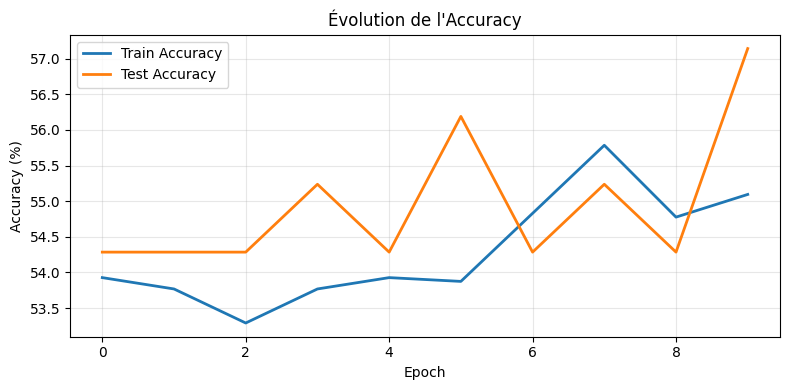

Accuracy finale - Train: 55.10% | Test: 57.14%


In [16]:
# Créer un CNN pour la classification CN/AD

# Choix du device (GPU si disponible)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

# Créer les datasets avec redimensionnement à 128x128
train_dataset = AdniDataset('dataset/train_adcn_augmented.txt', 'dataset/2D_slices_augmented/', mode='2d')
test_dataset = AdniDataset('dataset/test_adcn.txt', 'dataset/2D_slices/', mode='2d')

# Créer les DataLoaders
batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Partie convolutionnelle
conv_layers = nn.Sequential(
    # 128x128x1 -> 64x64x16 | 181x217x1 -> 90x108x16
    nn.Conv2d(1, 16, kernel_size=3, padding=1),
    nn.BatchNorm2d(16),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(2),

    # 64x64x16 -> 32x32x32 | 90x108x16 -> 45x54x32
    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(2),

    # 32x32x32 -> 16x16x64 | 45x54x32 -> 22x27x64
    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(2),

    # 16x16x64 -> 1x1x128 | 22x27x64 -> 1x1x128
    nn.Conv2d(64, 128, kernel_size=3, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(inplace=True),
    nn.AdaptiveAvgPool2d((1, 1)),

    nn.Flatten()
).to(device)

# Partie fully-connected
fc_layers = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 2)
)

# Modèle complet
model = nn.Sequential(conv_layers, fc_layers).to(device)

# Affichage
img_sample, _ = train_dataset[0]
print(f"\nTaille de l'image redimensionnée : {img_sample.shape}")
print(f"\nTaille du vecteur applati : 128")
print(f"\nNombre total de paramètres : {sum(p.numel() for p in model.parameters())}")


# Paramètres d'entraînement
n_epochs = 10
learning_rate = 0.0001
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Listes pour stocker les métriques
train_accs = []
test_accs = []

# Entraînement
print(f"\nEntraînement du CNN sur {n_epochs} epochs...")
for epoch in range(n_epochs):
    train_loss, train_acc = train_epoch(model, train_dataloader, loss_fn, optimizer, device)
    test_loss, test_acc = eval_epoch(model, test_dataloader, loss_fn, device)
    
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}% - "
              f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc*100:.2f}%")

print("Entraînement terminé !\n")

# Afficher les courbes
fig, axes = plt.subplots(figsize=(8, 4))

# Courbe des accuracies
axes.plot([acc * 100 for acc in train_accs], label='Train Accuracy', linewidth=2)
axes.plot([acc * 100 for acc in test_accs], label='Test Accuracy', linewidth=2)
axes.set_xlabel('Epoch')
axes.set_ylabel('Accuracy (%)')
axes.set_title('Évolution de l\'Accuracy')
axes.legend()
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Accuracy finale - Train: {train_accs[-1]*100:.2f}% | Test: {test_accs[-1]*100:.2f}%")

## ResNet18 avec remplacement de la tête de classification

Device : cuda

Chargement de ResNet18 pré-entraîné...
Paramètres total: 11242434 | Entraînables (tête): 65922

Entraînement de la tête ResNet18 sur 10 epochs (LR=0.001)...
Epoch 5/10 - Train Loss: 0.6850, Train Acc: 54.88% - Test Loss: 0.6656, Test Acc: 61.90%
Epoch 10/10 - Train Loss: 0.6777, Train Acc: 56.42% - Test Loss: 0.6533, Test Acc: 61.90%
Entraînement terminé !



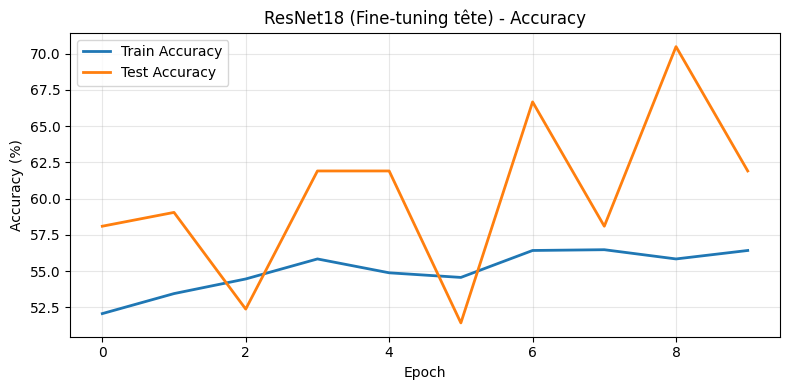

Accuracy finale - Train: 56.42% | Test: 61.90%
Écart Train/Test : -5.48%


In [17]:
# ResNet18 fine-tuning : entraînement seulement de la tête de classification
from torchvision import models
import torchvision.transforms as transforms
import torch.optim.lr_scheduler as lr_scheduler

# Choix du device (GPU si disponible)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

# Charger ResNet18 pré-entraîné
print("\nChargement de ResNet18 pré-entraîné...")
resnet18_full = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Geler tous les paramètres du réseau pré-entraîné
for param in resnet18_full.parameters():
    param.requires_grad = False

# Remplacer la dernière couche fc pour avoir 2 classes (CN/AD)
num_features = resnet18_full.fc.in_features
resnet18_full.fc = nn.Sequential(
    nn.Linear(num_features, 128),
    nn.ReLU(),
    nn.Linear(128, 2)
)

# Passage sur GPU
resnet18_full = resnet18_full.to(device)

# Vérifier que seule la tête est entraînable
trainable_params = sum(p.numel() for p in resnet18_full.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in resnet18_full.parameters())
print(f"Paramètres total: {total_params} | Entraînables (tête): {trainable_params}")

# Créer les datasets avec transformation pour ResNet18
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet mean
        std=[0.229, 0.224, 0.225]    # ImageNet std
    )
])

# Créer des datasets avec transformation adaptée
class AdniDatasetWithTransform(Dataset):
    def __init__(self, data_file_path, data_dir, mode='2d', transform=None):
        self.base_dataset = AdniDataset(data_file_path, data_dir, mode=mode)
        self.transform = transform
        self.label_names = self.base_dataset.label_names
        self.samples = self.base_dataset.samples
    
    def __len__(self):
        return len(self.base_dataset)
    
    def __getitem__(self, idx):
        tensor, label = self.base_dataset[idx]
        # Convertir en PIL pour transformer, puis revenir à tensor
        from PIL import Image
        img_array = (tensor[0].numpy() * 255).astype(np.uint8)
        # Convertir en RGB (dupliquer le canal pour passer de 1 à 3 canaux)
        img_rgb = np.stack([img_array, img_array, img_array], axis=2)
        img_pil = Image.fromarray(img_rgb)
        if self.transform:
            tensor = self.transform(img_pil)
        return tensor, label

# Chargement des datasets avec transformation
train_dataset_full = AdniDatasetWithTransform('dataset/train_adcn_augmented.txt', 'dataset/2D_slices_augmented/', mode='2d', transform=transform)
test_dataset_full = AdniDatasetWithTransform('dataset/test_adcn.txt', 'dataset/2D_slices/', mode='2d', transform=transform)

batch_size = 32
train_dataloader_full = DataLoader(train_dataset_full, batch_size=batch_size, shuffle=True)
test_dataloader_full = DataLoader(test_dataset_full, batch_size=batch_size, shuffle=False)

# Paramètres d'entraînement
n_epochs = 10
learning_rate = 0.001  # Learning rate plus élevé car seule la tête est entraînée
loss_fn = nn.CrossEntropyLoss()

# Optimizer uniquement sur la tête de classification
optimizer_full = torch.optim.Adam(resnet18_full.fc.parameters(), lr=learning_rate)

# Learning rate scheduler
scheduler_full = lr_scheduler.StepLR(optimizer_full, step_size=10, gamma=0.5)

# Listes pour stocker les métriques
train_accs_full = []
test_accs_full = []
train_losses_full = []
test_losses_full = []

# Entraînement
print(f"\nEntraînement de la tête ResNet18 sur {n_epochs} epochs (LR={learning_rate})...")
for epoch in range(n_epochs):
    train_loss, train_acc = train_epoch(resnet18_full, train_dataloader_full, loss_fn, optimizer_full, device)
    test_loss, test_acc = eval_epoch(resnet18_full, test_dataloader_full, loss_fn, device)
    
    train_accs_full.append(train_acc)
    test_accs_full.append(test_acc)
    train_losses_full.append(train_loss)
    test_losses_full.append(test_loss)
    
    scheduler_full.step()
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}% - "
              f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc*100:.2f}%")

print("Entraînement terminé !\n")

# Afficher les courbes
fig, axes = plt.subplots(figsize=(8, 4))

# Courbe des accuracies
axes.plot([acc * 100 for acc in train_accs_full], label='Train Accuracy', linewidth=2)
axes.plot([acc * 100 for acc in test_accs_full], label='Test Accuracy', linewidth=2)
axes.set_xlabel('Epoch')
axes.set_ylabel('Accuracy (%)')
axes.set_title('ResNet18 (Fine-tuning tête) - Accuracy')
axes.legend()
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Accuracy finale - Train: {train_accs_full[-1]*100:.2f}% | Test: {test_accs_full[-1]*100:.2f}%")
print(f"Écart Train/Test : {(train_accs_full[-1] - test_accs_full[-1])*100:.2f}%")

## Test MCI

Nombre d'images MCI de test : 300

Distribution des classes MCI:
  sMCI (label 2): 171 images (57.00%)
  pMCI (label 3): 129 images (43.00%)

RÉSULTATS RESNET18 SUR DONNÉES TEST MCI

Accuracy ResNet18 sur test MCI: 0.00%
Prédictions correctes: 0/300

Matrice de confusion (2x2):
                CN    AD
sMCI       [ 74    97]
pMCI       [ 75    54]


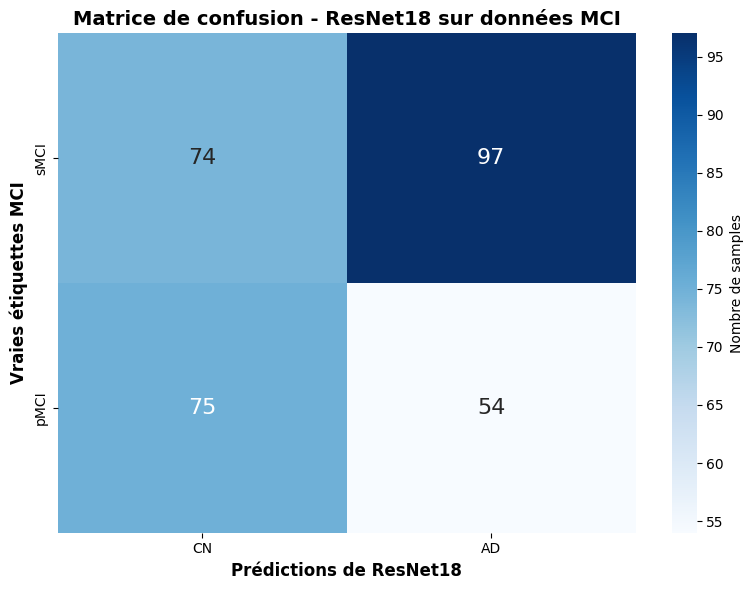

In [18]:
# Charger le dataset de test MCI
test_mci_dataset = AdniDatasetWithTransform('dataset/test_mci.txt', 'dataset/2D_slices/', mode='2d', transform=transform)
test_mci_dataloader = DataLoader(test_mci_dataset, batch_size=batch_size, shuffle=False)

print(f"Nombre d'images MCI de test : {len(test_mci_dataset)}")
print(f"\nDistribution des classes MCI:")
label_counts_mci = {}
for i in range(len(test_mci_dataset)):
    label = test_mci_dataset.samples[i][1]
    label_counts_mci[label] = label_counts_mci.get(label, 0) + 1

for label_id, count in sorted(label_counts_mci.items()):
    label_name = test_mci_dataset.label_names[label_id]
    percentage = (count / len(test_mci_dataset)) * 100
    print(f"  {label_name} (label {label_id}): {count} images ({percentage:.2f}%)")

# Évaluer le modèle ResNet18 sur les données MCI
print("\n" + "="*60)
print("RÉSULTATS RESNET18 SUR DONNÉES TEST MCI")
print("="*60)

# Assurer que le modèle est sur le bon device
resnet18_full = resnet18_full.to(device)
resnet18_full.eval()

correct_mci = 0
total_mci = 0
predictions = []
true_labels = []

with torch.no_grad():
    for X, y in test_mci_dataloader:
        X, y = X.to(device), y.to(device)
        y_pred = resnet18_full(X)
        
        # Récupérer les prédictions
        pred_labels = y_pred.argmax(dim=1)
        
        # Pour l'accuracy: comparer les predictions avec les vraies labels
        correct_mci += (pred_labels == y).sum().item()
        total_mci += y.size(0)
        
        predictions.extend(pred_labels.cpu().numpy())
        true_labels.extend(y.cpu().numpy())

accuracy_mci = correct_mci / total_mci

print(f"\nAccuracy ResNet18 sur test MCI: {accuracy_mci*100:.2f}%")
print(f"Prédictions correctes: {correct_mci}/{total_mci}")

# Matrice de confusion pour ResNet18 vs MCI
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compter les prédictions par classe MCI
sMCI_to_CN = sum(1 for true, pred in zip(true_labels, predictions) if true == 2 and pred == 0)
sMCI_to_AD = sum(1 for true, pred in zip(true_labels, predictions) if true == 2 and pred == 1)
pMCI_to_CN = sum(1 for true, pred in zip(true_labels, predictions) if true == 3 and pred == 0)
pMCI_to_AD = sum(1 for true, pred in zip(true_labels, predictions) if true == 3 and pred == 1)

# Créer la matrice 2x2
cm_2x2 = [[sMCI_to_CN, sMCI_to_AD],
          [pMCI_to_CN, pMCI_to_AD]]

print(f"\nMatrice de confusion (2x2):")
print(f"                CN    AD")
print(f"sMCI       [{sMCI_to_CN:3d}   {sMCI_to_AD:3d}]")
print(f"pMCI       [{pMCI_to_CN:3d}   {pMCI_to_AD:3d}]")

# Afficher la matrice de confusion 2x2 avec matplotlib
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(cm_2x2, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['CN', 'AD'], 
            yticklabels=['sMCI', 'pMCI'],
            cbar_kws={'label': 'Nombre de samples'},
            ax=ax,
            annot_kws={'size': 16})

ax.set_xlabel('Prédictions de ResNet18', fontsize=12, fontweight='bold')
ax.set_ylabel('Vraies étiquettes MCI', fontsize=12, fontweight='bold')
ax.set_title('Matrice de confusion - ResNet18 sur données MCI', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## U Map

/home/francoisverry/Documents/eia-04/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/francoisverry/Documents/eia-04/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


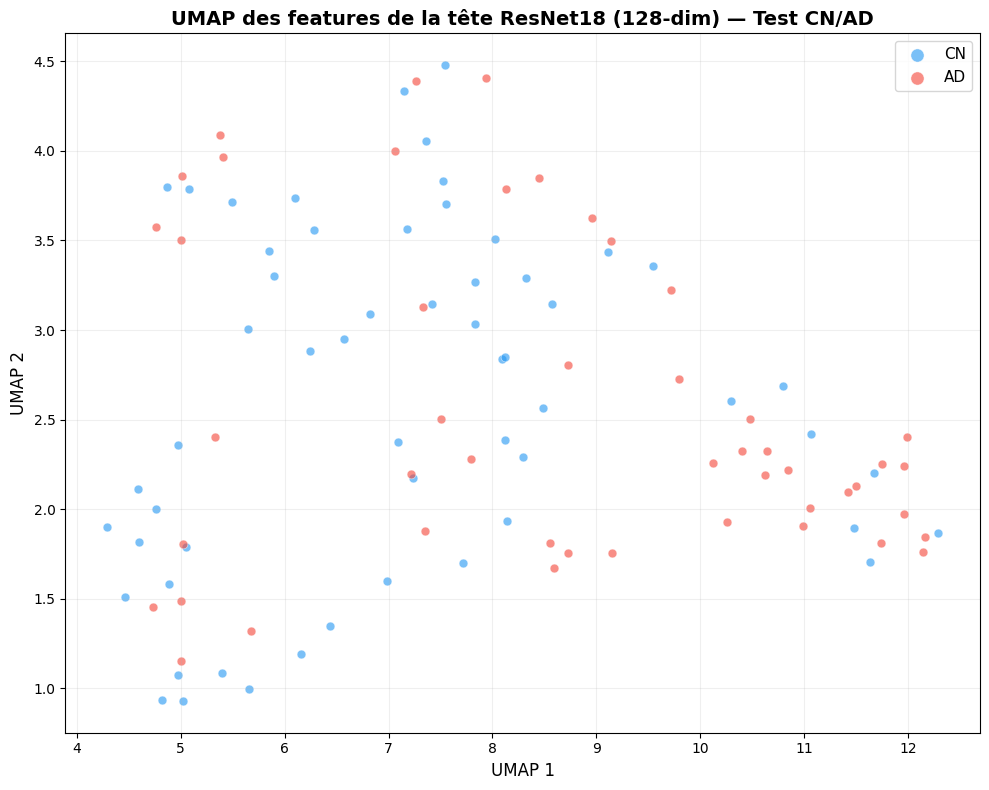

In [19]:
# Visualisation UMAP des features ResNet18 (test CN/AD)
import umap

# Extraire les features après la 1ère couche de la tête FC (représentation 128-dim)
def extract_features(model, dataloader, device):
    model.eval()
    features = []
    labels = []
    hook_output = []
    # Hook sur la ReLU de la tête : fc = Sequential(Linear(512,128), ReLU, Linear(128,2))
    hook = model.fc[1].register_forward_hook(lambda m, inp, out: hook_output.append(out))
    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            hook_output.clear()
            _ = model(X)
            feat = hook_output[0]  # (batch, 128)
            if feat.dim() == 1:
                feat = feat.unsqueeze(0)
            features.append(feat.cpu().numpy())
            labels.extend(y.numpy())
    hook.remove()
    return np.concatenate(features, axis=0), np.array(labels)

# Extraire les features pour test CN/AD
features_adcn, labels_adcn = extract_features(resnet18_full, test_dataloader_full, device)

# Projection UMAP en 2D
reducer = umap.UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(features_adcn)

# Affichage
label_names_umap = {0: 'CN', 1: 'AD'}
colors = {0: '#2196F3', 1: '#F44336'}

fig, ax = plt.subplots(figsize=(10, 8))

for label_id in [0, 1]:
    mask = labels_adcn == label_id
    ax.scatter(embedding[mask, 0], embedding[mask, 1],
               c=colors[label_id], label=label_names_umap[label_id],
               alpha=0.6, s=40, edgecolors='white', linewidth=0.5)

ax.set_xlabel('UMAP 1', fontsize=12)
ax.set_ylabel('UMAP 2', fontsize=12)
ax.set_title('UMAP des features de la tête ResNet18 (128-dim) — Test CN/AD', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, markerscale=1.5)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

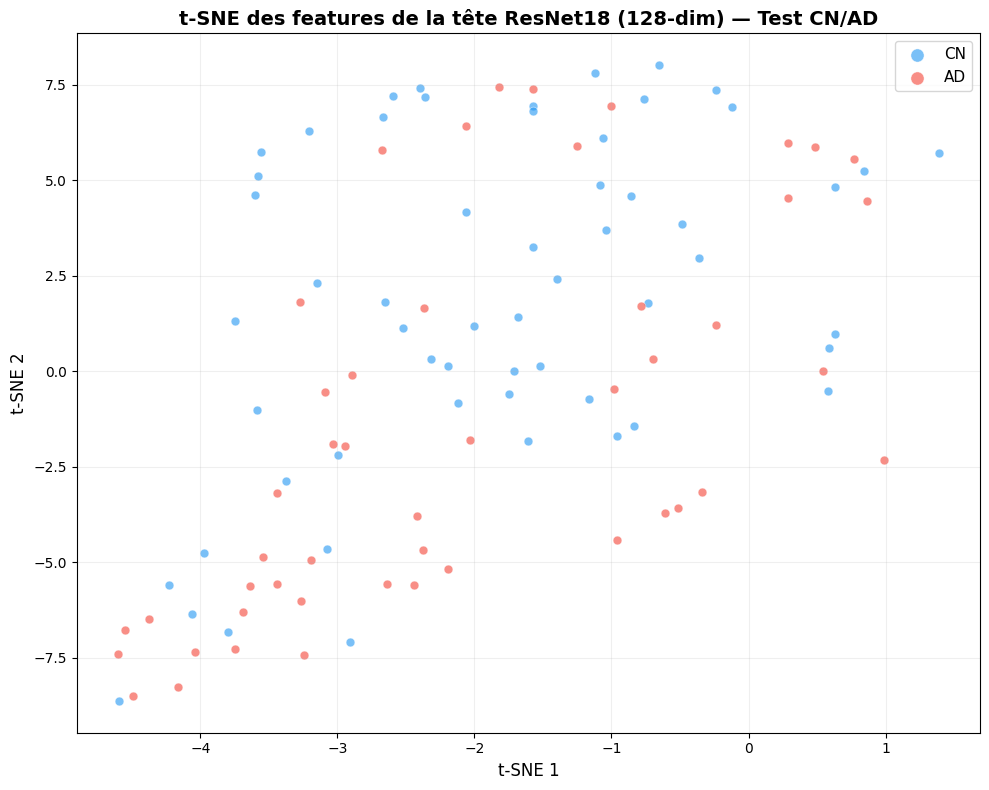

In [20]:
# Visualisation t-SNE des features ResNet18 (test CN/AD)
from sklearn.manifold import TSNE

# Projection t-SNE en 2D (features 128-dim déjà extraites dans la cellule UMAP)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embedding_tsne = tsne.fit_transform(features_adcn)

# Affichage
label_names_tsne = {0: 'CN', 1: 'AD'}
colors_tsne = {0: '#2196F3', 1: '#F44336'}

fig, ax = plt.subplots(figsize=(10, 8))

for label_id in [0, 1]:
    mask = labels_adcn == label_id
    ax.scatter(embedding_tsne[mask, 0], embedding_tsne[mask, 1],
               c=colors_tsne[label_id], label=label_names_tsne[label_id],
               alpha=0.6, s=40, edgecolors='white', linewidth=0.5)

ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_title('t-SNE des features de la tête ResNet18 (128-dim) — Test CN/AD', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, markerscale=1.5)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

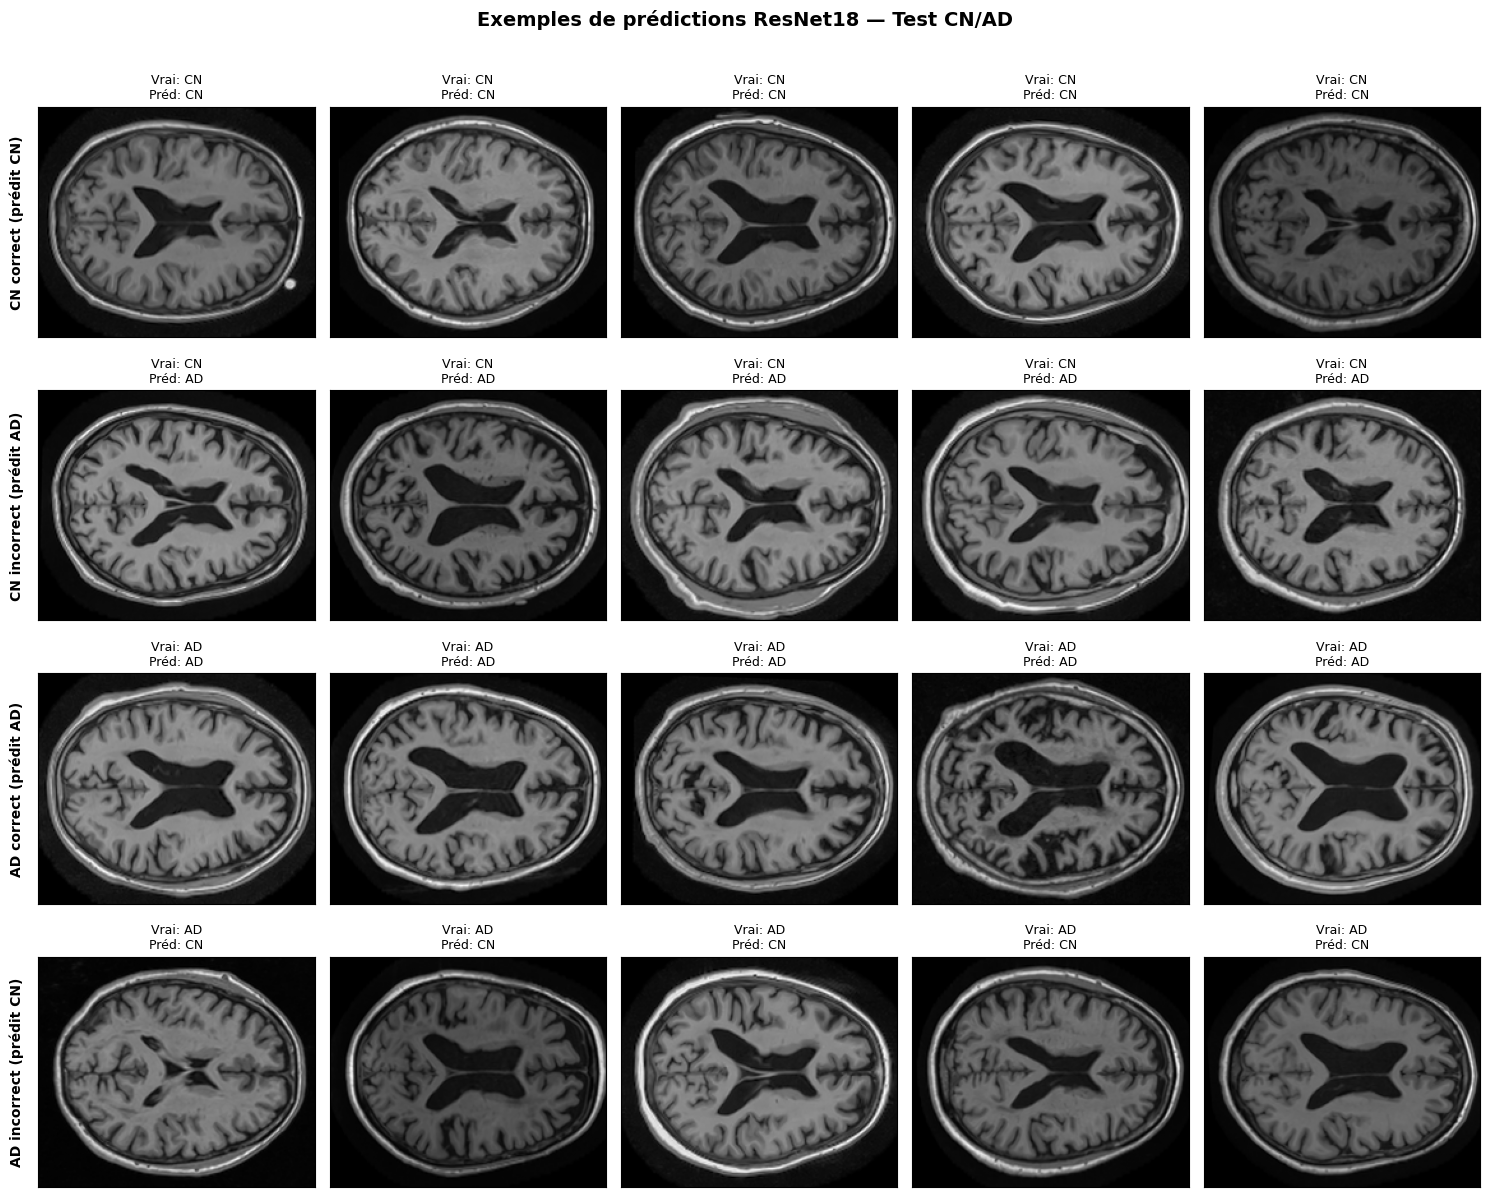

CN : 33 corrects, 24 incorrects
AD : 32 corrects, 16 incorrects


In [21]:
# Exemples de prédictions correctes et incorrectes pour CN et AD
import random

resnet18_full.eval()
correct_cn, incorrect_cn = [], []
correct_ad, incorrect_ad = [], []

with torch.no_grad():
    for idx in range(len(test_dataset_full)):
        X, y = test_dataset_full[idx]
        X_batch = X.unsqueeze(0).to(device)
        pred = resnet18_full(X_batch).argmax(dim=1).item()
        true = y.item()
        # Récupérer l'image originale (niveaux de gris) pour l'affichage
        img_gray = test_dataset_full.base_dataset[idx][0][0].numpy()
        entry = (img_gray, true, pred)
        if true == 0:  # CN
            (correct_cn if pred == 0 else incorrect_cn).append(entry)
        else:  # AD
            (correct_ad if pred == 1 else incorrect_ad).append(entry)

# Sélectionner jusqu'à 5 exemples par catégorie
n = 5
random.seed(42)
samples = {
    'CN correct (prédit CN)': random.sample(correct_cn, min(n, len(correct_cn))),
    'CN incorrect (prédit AD)': random.sample(incorrect_cn, min(n, len(incorrect_cn))),
    'AD correct (prédit AD)': random.sample(correct_ad, min(n, len(correct_ad))),
    'AD incorrect (prédit CN)': random.sample(incorrect_ad, min(n, len(incorrect_ad))),
}

fig, axes = plt.subplots(4, n, figsize=(3 * n, 12))

for row, (title, examples) in enumerate(samples.items()):
    for col in range(n):
        ax = axes[row, col]
        if col < len(examples):
            img, true, pred = examples[col]
            ax.imshow(img, cmap='gray')
            label_names = {0: 'CN', 1: 'AD'}
            ax.set_title(f'Vrai: {label_names[true]}\nPréd: {label_names[pred]}', fontsize=9)
        else:
            ax.axis('off')
            continue
        ax.set_xticks([])
        ax.set_yticks([])
    axes[row, 0].set_ylabel(title, fontsize=10, fontweight='bold', rotation=90, labelpad=10)

plt.suptitle('Exemples de prédictions ResNet18 — Test CN/AD', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'CN : {len(correct_cn)} corrects, {len(incorrect_cn)} incorrects')
print(f'AD : {len(correct_ad)} corrects, {len(incorrect_ad)} incorrects')